---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Multivariate Time Series

## 1\. Introduction to Multivariate Time Series

In modern finance, analyzing a single asset in isolation is often insufficient. Portfolios consist of multiple assets, and the price movements of one asset are often correlated with others. When we observe multiple time series simultaneously, we use Multivariate Time Series analysis.

::: {#def-multivariate-ts}
## Multivariate Time Series Vector
Let there be $k$ assets. At time $t$, the returns of these assets form a $k$-dimensional vector:
$$
\vec{r}_t = (r_{1t}, r_{2t}, \dots, r_{kt})^T
$$
where $r_{it}$ is the return of asset $i$ at time $t$, and $T$ denotes the transpose.
:::

## 2\. Cross-Covariance and Cross-Correlation

For a single variable, we analyzed the linear dependence over time using **[autocorrelation](autocorrelation-and-stationarity.ipynb)**. For multiple variables, we need to analyze the linear dependence across both time and assets. This is called **cross-correlation**.

::: {#def-cross-covariance}
## Cross-Covariance Matrix
For a weakly stationary multivariate time series with mean vector $\vec{\mu} = E[\vec{r}_t]$, the cross-covariance matrix at lag $\ell$ is defined as:
$$
\Gamma(\ell) = \text{Cov}(\vec{r}_t, \vec{r}_{t-\ell}) = E[(\vec{r}_t - \vec{\mu})(\vec{r}_{t-\ell} - \vec{\mu})^T]
$$
The element at row $i$ and column $j$ of $\Gamma(\ell)$, denoted $\Gamma_{ij}(\ell)$, is the cross-covariance between asset $i$ at time $t$ and asset $j$ at time $t-\ell$:
$$
\Gamma_{ij}(\ell) = \text{Cov}(r_{it}, r_{j,t-\ell})
$$
:::

::: {.callout-warning}
## Asymmetry of Cross-Covariance
Unlike the autocovariance of a single series where $\gamma_\ell = \gamma_{-\ell}$, the cross-covariance matrix is generally not symmetric, i.e., $\Gamma(\ell) \neq \Gamma(\ell)^T$. However, the property $\Gamma_{ij}(\ell) = \Gamma_{ji}(-\ell)$ holds.
:::

::: {#def-cross-correlation}
## Cross-Correlation Matrix
To standardize the cross-covariance into a correlation metric (between -1 and 1), we define the cross-correlation matrix $\rho(\ell)$. Its individual elements are:
$$
\rho_{ij}(\ell) = \frac{\Gamma_{ij}(\ell)}{\sqrt{\Gamma_{ii}(0) \Gamma_{jj}(0)}}
$$
where $\Gamma_{ii}(0)$ is the variance of asset $i$, and $\Gamma_{jj}(0)$ is the variance of asset $j$.
:::

In matrix notation, we can write the cross-correlation matrix as:
$$
\rho(\ell) = D^{-1} \Gamma(\ell) D^{-1}
$$
where $D$ is a diagonal matrix containing the standard deviations of the individual assets (i.e., $D = \text{diag}(\sqrt{\Gamma_{11}(0)}, \dots, \sqrt{\Gamma_{kk}(0)})$).

## 3\. Weak Stationarity Assumption

The assumption of [weak stationarity](autocorrelation-and-stationarity.ipynb) for a multivariate time series requires that:
1. The mean vector $\vec{\mu}$ does not depend on time $t$.
2. The cross-covariance matrix $\Gamma(\ell)$ depends only on the lag $\ell$, and not on the time $t$.




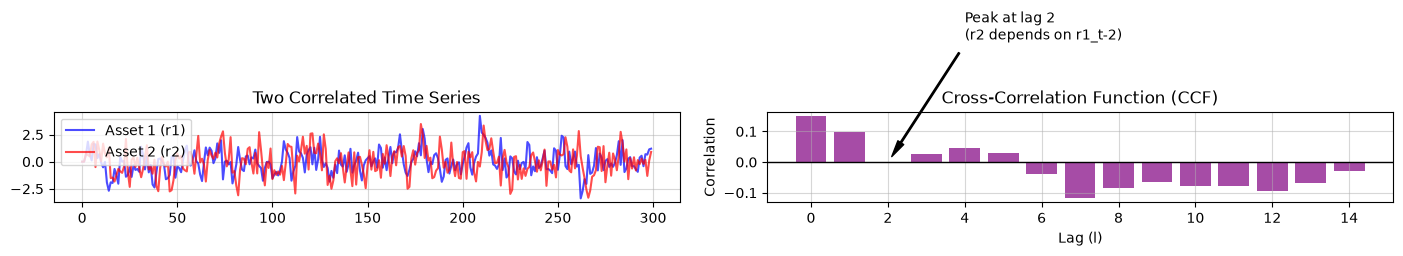

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

np.random.seed(42)

# Simulate two correlated time series
# r1_t = 0.5 * r1_{t-1} + a_t
# r2_t = 0.8 * r1_{t-2} + b_t  (r2 lags r1 by 2 periods)

T = 300
a = np.random.normal(0, 1, T)
b = np.random.normal(0, 1, T)

r1 = np.zeros(T)
r2 = np.zeros(T)

for t in range(2, T):
    r1[t] = 0.5 * r1[t-1] + a[t]
    r2[t] = 0.8 * r1[t-2] + b[t]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the two series
axes[0].plot(r1, label="Asset 1 (r1)", color='blue', alpha=0.7)
axes[0].plot(r2, label="Asset 2 (r2)", color='red', alpha=0.7)
axes[0].set_title("Two Correlated Time Series")
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Calculate and plot Cross-Correlation Function (CCF)
# We want to see the correlation between r1_t and r2_{t-lag}
# statsmodels ccf computes correlation of first array with lags of second array
cross_corr = ccf(r1, r2, adjusted=False)[:15]

axes[1].bar(range(15), cross_corr, color='purple', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title("Cross-Correlation Function (CCF)")
axes[1].set_xlabel("Lag (l)")
axes[1].set_ylabel("Correlation")
axes[1].grid(True, alpha=0.5)

# Highlight the peak at lag 2
axes[1].annotate('Peak at lag 2\n(r2 depends on r1_t-2)', 
                 xy=(2, cross_corr[2]), xytext=(4, 0.4),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.